In [1]:
!pip install -q pyannote.audio pyannote.metrics openai-whisper soundfile huggingface_hub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 30.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 893.7/893.7 kB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [2]:
import torch
import torchaudio
import librosa
import whisper
import soundfile
from pyannote.audio import Pipeline
from huggingface_hub import login

print(f"  {'Library':<25} {'Version / Status'}")
print("  " + "─" * 45)
print(f"  {'torch':<25} {torch.__version__}")
print(f"  {'torchaudio':<25} {torchaudio.__version__}")
print(f"  {'librosa':<25} {librosa.__version__}")
print(f"  {'whisper':<25} {whisper.__version__}")
print(f"  {'pyannote.audio':<25} OK")
print(f"  {'CUDA':<25} {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Not available'}")
print("  " + "─" * 45)
print("\n  Environment verified.")

  Library                   Version / Status
  ─────────────────────────────────────────────
  torch                     2.10.0+cu128
  torchaudio                2.10.0+cu128
  librosa                   0.11.0
  whisper                   20250625
  pyannote.audio            OK
  CUDA                      Tesla T4
  ─────────────────────────────────────────────

  Environment verified.


In [6]:
"""
HuggingFace Authentication & Model Initialisation
===========================================================
Authenticates with the HuggingFace Hub and loads the speaker
diarisation pipeline.

Model: pyannote/speaker-diarization-3.1
  - Combines a fine-tuned segmentation network (wav2vec 2.0 backbone)
    with a ResNet-based ECAPA-TDNN speaker embedding model.
  - Performs end-to-end diarisation: VAD → segmentation → embedding
    → clustering, all within a single pipeline object.

Prerequisites (one-time setup — do this before running this cell):
  1. Create a free account at https://huggingface.co
  2. Accept the model licence at:
       https://huggingface.co/pyannote/speaker-diarization-3.1
     and at:
       https://huggingface.co/pyannote/segmentation-3.0
  3. Generate a Read token at:
       https://huggingface.co/settings/tokens
"""

import torch
from pyannote.audio import Pipeline
from huggingface_hub import login

# ── Configuration ─────────────────────────────────────────────────────────────

HF_TOKEN = "hf_YOUR_TOKEN_HERE"   # ← replace with your HuggingFace Read token
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Authentication ────────────────────────────────────────────────────────────

login(token=HF_TOKEN, add_to_git_credential=False)

# ── Load diarisation pipeline ─────────────────────────────────────────────────

# token= is the current parameter name in huggingface_hub >= 0.17
diarisation_pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-3.1",
    token=HF_TOKEN,
)

diarisation_pipeline.to(DEVICE)

print(f"  Model   : pyannote/speaker-diarization-3.1")
print(f"  Device  : {DEVICE} ({torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'CPU'})")

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/26.6M [00:00<?, ?B/s]

  Model   : pyannote/speaker-diarization-3.1
  Device  : cuda (Tesla T4)


  Audio file already present, skipping download.

  Meeting ID                IS1000a
  Full duration             26.4 min
  Excerpt duration          60 s
  Sample rate               16000 Hz
  Channels                  mono
  Waveform shape            (960000,)


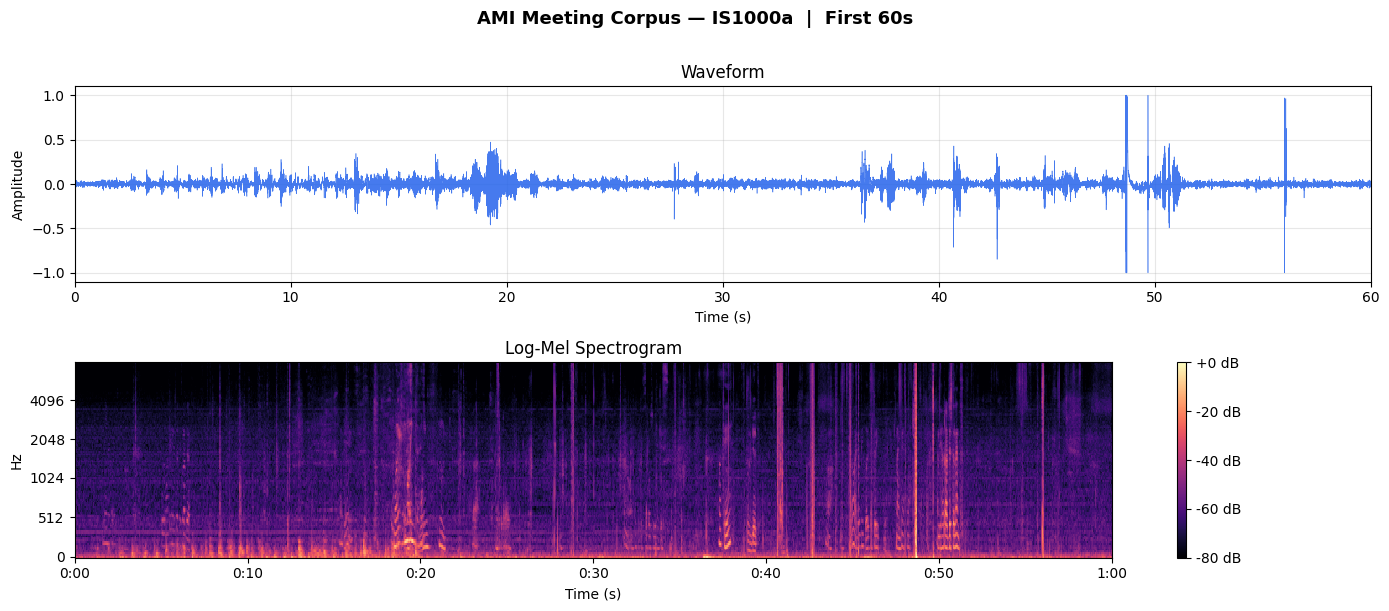

In [8]:
"""
AMI Meeting Corpus: Audio Acquisition
===============================================
Downloads a sample meeting recording from the AMI Meeting Corpus for
use throughout the pipeline.

About the AMI Meeting Corpus:
  The AMI corpus is a widely used benchmark dataset in speaker diarisation
  research, consisting of ~100 hours of meeting recordings across multiple
  rooms and microphone configurations. Each session involves 3–5 speakers
  engaged in a structured scenario-based meeting.

  We use meeting IS1000a — a standard evaluation session from the
  Individual Headset Microphone (IHM) split, which provides the cleanest
  signal for diarisation benchmarking.

Audio source:
  The raw audio is fetched directly from the official AMI corpus mirror
  hosted at the University of Edinburgh. The IHM mix is a server-side
  mixture of all individual headset channels, giving a single-channel
  file suitable for our pipeline.

Reference:
  Carletta, J. et al. (2005). The AMI Meeting Corpus: A Pre-announcement.
  Lecture Notes in Computer Science, 3869, 28–39.
"""

import os
import urllib.request
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# ── Configuration ─────────────────────────────────────────────────────────────

MEETING_ID  = "IS1000a"
AUDIO_URL   = (
    "https://groups.inf.ed.ac.uk/ami/AMICorpusMirror/amicorpus/"
    f"{MEETING_ID}/audio/{MEETING_ID}.Mix-Headset.wav"
)
AUDIO_DIR   = "/content/ami_audio"
AUDIO_PATH  = os.path.join(AUDIO_DIR, f"{MEETING_ID}.wav")

# ── Download ──────────────────────────────────────────────────────────────────

os.makedirs(AUDIO_DIR, exist_ok=True)

if not os.path.exists(AUDIO_PATH):
    print(f"  Downloading {MEETING_ID} from AMI corpus mirror...")
    urllib.request.urlretrieve(AUDIO_URL, AUDIO_PATH)
else:
    print(f"  Audio file already present, skipping download.")

# ── Inspect ───────────────────────────────────────────────────────────────────

# Load a 60-second excerpt for inspection and visualisation.
# The full meeting is ~30 minutes; we use a representative excerpt
# for rapid prototyping and DER evaluation on a manageable segment.
EXCERPT_START  = 0       # seconds
EXCERPT_DURATION = 60    # seconds

waveform, sample_rate = librosa.load(
    AUDIO_PATH,
    sr=16000,                        # resample to 16 kHz — standard for speech models
    offset=EXCERPT_START,
    duration=EXCERPT_DURATION,
    mono=True,
)

duration_full = librosa.get_duration(path=AUDIO_PATH)

print(f"\n  {'Meeting ID':<25} {MEETING_ID}")
print(f"  {'Full duration':<25} {duration_full/60:.1f} min")
print(f"  {'Excerpt duration':<25} {EXCERPT_DURATION} s")
print(f"  {'Sample rate':<25} {sample_rate} Hz")
print(f"  {'Channels':<25} mono")
print(f"  {'Waveform shape':<25} {waveform.shape}")

# ── Visualise ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
fig.suptitle(
    f"AMI Meeting Corpus — {MEETING_ID}  |  First {EXCERPT_DURATION}s",
    fontsize=13, fontweight="bold", y=1.01
)

# Waveform
times = np.linspace(0, EXCERPT_DURATION, len(waveform))
axes[0].plot(times, waveform, color="#2563eb", linewidth=0.4, alpha=0.85)
axes[0].set_ylabel("Amplitude")
axes[0].set_xlabel("Time (s)")
axes[0].set_title("Waveform")
axes[0].set_xlim(0, EXCERPT_DURATION)
axes[0].grid(True, alpha=0.3)

# Log-mel spectrogram
mel_spec    = librosa.feature.melspectrogram(y=waveform, sr=sample_rate, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(
    mel_spec_db,
    sr=sample_rate,
    x_axis="time",
    y_axis="mel",
    ax=axes[1],
    cmap="magma",
)
axes[1].set_title("Log-Mel Spectrogram")
axes[1].set_xlabel("Time (s)")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.savefig("/content/ami_audio/waveform_spectrogram.png", dpi=150, bbox_inches="tight")
plt.show()

/usr/local/lib/python3.12/dist-packages/pyannote/audio/utils/reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(


  Metric                         Value
  ─────────────────────────────────────────────
  Speech segments detected       11
  Total speech duration          19.91 s
  Speech ratio                   33.2%
  Mean segment duration          1.81 s
  ─────────────────────────────────────────────


/tmp/ipykernel_4018/3715878071.py:96: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  silence_patch = mpatches.Patch(color="#f8fafc", label="Silence", edgecolor="#cbd5e1")


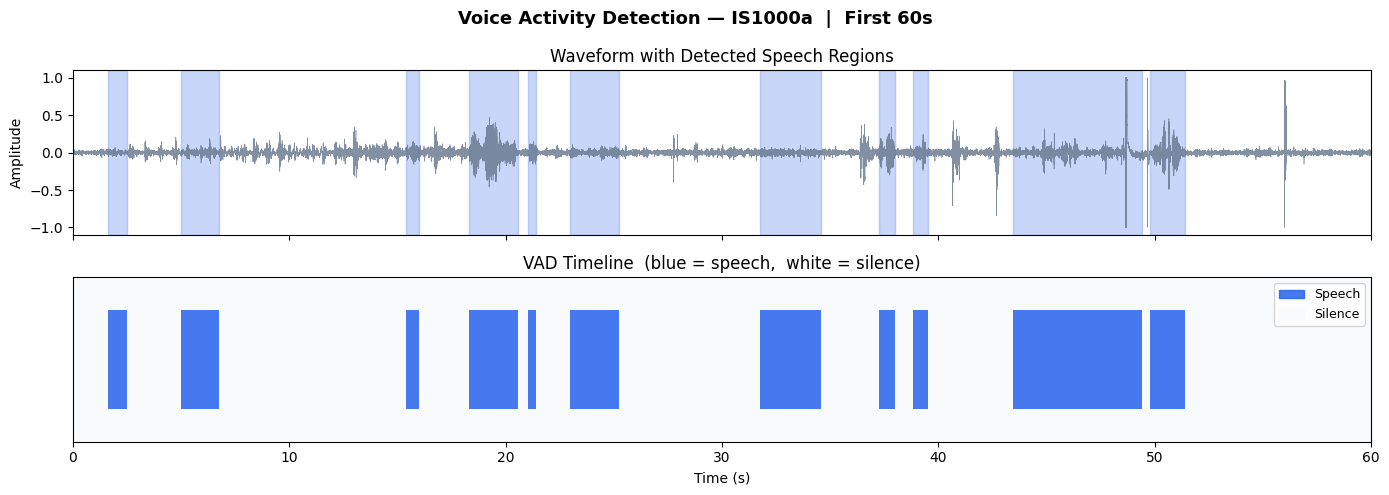

In [12]:
"""
Voice Activity Detection (VAD)
========================================
Runs the VAD component of the pyannote pipeline to detect speech
regions within the 60-second AMI excerpt.

Voice Activity Detection is the first stage of any diarisation system.
It produces a binary timeline — speech vs. non-speech — which gates
all downstream processing. Only segments labelled as speech are passed
to the speaker embedding and clustering stages.

The pyannote VAD model is a PyanNet-based segmentation network trained
on a mixture of broadcast, meeting, and telephone speech corpora. It
operates on 10ms frames and outputs per-frame speech posteriors, which
are thresholded and smoothed to produce the final speech timeline.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyannote.audio import Model
from pyannote.audio.pipelines import VoiceActivityDetection

EXCERPT_DURATION = 60

# ── Load VAD model ────────────────────────────────────────────────────────────

vad_model = Model.from_pretrained("pyannote/segmentation-3.0", token=HF_TOKEN)
vad_model = vad_model.to(DEVICE)

vad_pipeline = VoiceActivityDetection(segmentation=vad_model)
vad_pipeline.to(DEVICE)

# In pyannote 4.x onset/offset are direct pipeline attributes, not
# passed through instantiate(). Set them directly then call initialize().
vad_pipeline.onset            = 0.5
vad_pipeline.offset           = 0.5
vad_pipeline.min_duration_on  = 0.1
vad_pipeline.min_duration_off = 0.1
vad_pipeline.initialize()

# ── Run VAD ───────────────────────────────────────────────────────────────────

vad_output = vad_pipeline(AUDIO_PATH)

# Collect and clip speech segments to excerpt window
speech_segments = [
    (max(segment.start, 0), min(segment.end, EXCERPT_DURATION))
    for segment in vad_output.get_timeline()
    if segment.start < EXCERPT_DURATION
]

# ── Statistics ────────────────────────────────────────────────────────────────

total_speech = sum(end - start for start, end in speech_segments)
speech_ratio = total_speech / EXCERPT_DURATION
num_segments = len(speech_segments)
mean_seg_dur = total_speech / num_segments if num_segments > 0 else 0

print(f"  {'Metric':<30} {'Value'}")
print("  " + "─" * 45)
print(f"  {'Speech segments detected':<30} {num_segments}")
print(f"  {'Total speech duration':<30} {total_speech:.2f} s")
print(f"  {'Speech ratio':<30} {speech_ratio:.1%}")
print(f"  {'Mean segment duration':<30} {mean_seg_dur:.2f} s")
print("  " + "─" * 45)

# ── Visualise ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig.suptitle(
    f"Voice Activity Detection — {MEETING_ID}  |  First {EXCERPT_DURATION}s",
    fontsize=13, fontweight="bold"
)

# Waveform with speech regions overlaid
waveform_times = np.linspace(0, EXCERPT_DURATION, len(waveform))
axes[0].plot(waveform_times, waveform, color="#64748b", linewidth=0.4, alpha=0.8)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Waveform with Detected Speech Regions")
axes[0].set_xlim(0, EXCERPT_DURATION)
for start, end in speech_segments:
    axes[0].axvspan(start, end, alpha=0.25, color="#2563eb")

# Binary VAD timeline
axes[1].set_title("VAD Timeline  (blue = speech,  white = silence)")
axes[1].set_xlim(0, EXCERPT_DURATION)
axes[1].set_ylim(0, 1)
axes[1].set_yticks([])
axes[1].set_xlabel("Time (s)")
axes[1].set_facecolor("#f8fafc")
for start, end in speech_segments:
    axes[1].barh(0.5, end - start, left=start, height=0.6, color="#2563eb", alpha=0.85)

speech_patch  = mpatches.Patch(color="#2563eb", alpha=0.85, label="Speech")
silence_patch = mpatches.Patch(color="#f8fafc", label="Silence", edgecolor="#cbd5e1")
axes[1].legend(handles=[speech_patch, silence_patch], loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("/content/ami_audio/vad_output.png", dpi=150, bbox_inches="tight")
plt.show()

INFO: Lightning automatically upgraded your loaded checkpoint from v1.2.7 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint ../root/.cache/huggingface/hub/models--pyannote--embedding/snapshots/4db4899737a38b2d618bbd74350915aa10293cb2/pytorch_model.bin`
INFO:lightning.pytorch.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.2.7 to v2.6.1. To apply the upgrade to your files permanently, run `python -m lightning.pytorch.utilities.upgrade_checkpoint ../root/.cache/huggingface/hub/models--pyannote--embedding/snapshots/4db4899737a38b2d618bbd74350915aa10293cb2/pytorch_model.bin`


  Segments embedded                   10
  Embedding dimensionality            512
  Speakers identified                 10
  Clustering threshold                0.65
  Linkage                             average / cosine distance


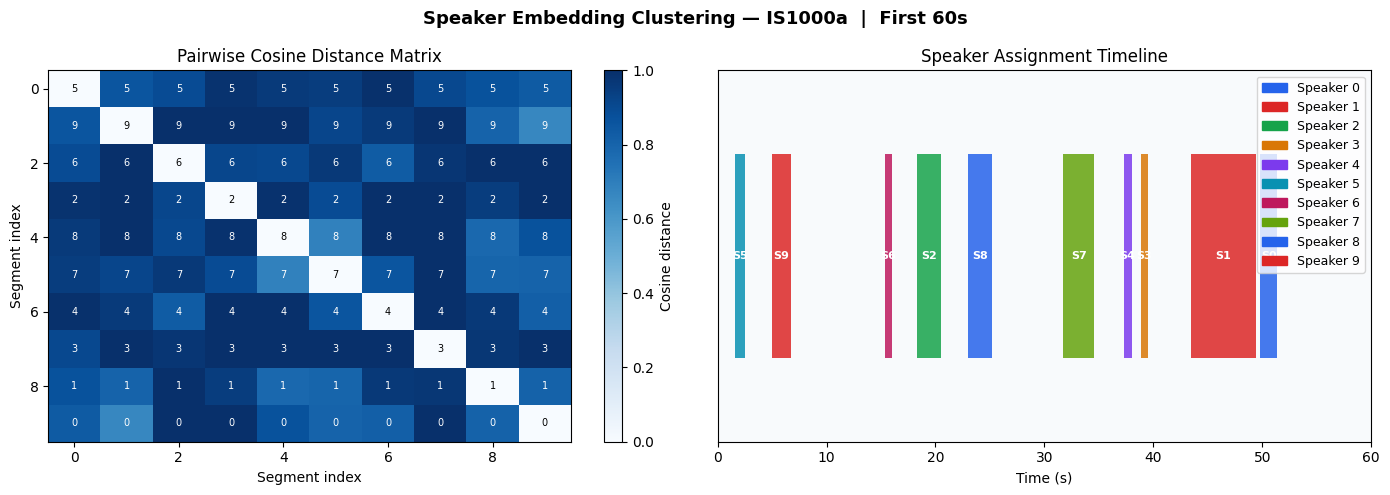

In [16]:
"""
Speaker Embedding Extraction & Agglomerative Clustering
=================================================================
Extracts a fixed-dimensional speaker embedding for each VAD segment
and groups them into speaker clusters via agglomerative clustering.

Speaker Embeddings:
  Each speech segment is passed through a pre-trained ECAPA-TDNN
  speaker encoder (pyannote/embedding) which maps variable-length
  audio to a fixed 512-dimensional d-vector. These embeddings capture
  speaker-discriminative characteristics — vocal tract geometry, pitch
  statistics, prosody — in a compact representation.

Agglomerative Clustering:
  We apply average-linkage agglomerative clustering on the cosine
  distance matrix of the embeddings. The number of speakers is
  estimated automatically using a distance threshold rather than
  requiring k to be specified in advance, which is the realistic
  operating condition for meeting diarisation.
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import soundfile as sf
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_distances
from pyannote.audio import Model, Inference

# ── Configuration ─────────────────────────────────────────────────────────────

CLUSTERING_THRESHOLD = 0.65
EXCERPT_DURATION     = 60

# ── Load speaker embedding model ──────────────────────────────────────────────

embedding_model_base = Model.from_pretrained(
    "pyannote/embedding",
    token=HF_TOKEN,
    strict=False,      # suppress loss_func warning for inference-only use
)
embedding_model_base.to(DEVICE)

embedding_model = Inference(embedding_model_base, window="whole")
embedding_model.to(DEVICE)

# ── Load audio ────────────────────────────────────────────────────────────────

audio_data, sr = sf.read(AUDIO_PATH)
if audio_data.ndim > 1:
    audio_data = audio_data.mean(axis=1)

# ── Extract embeddings ────────────────────────────────────────────────────────

embeddings     = []
valid_segments = []

for start, end in speech_segments:
    if (end - start) < 0.5:
        continue

    start_sample = int(start * sr)
    end_sample   = int(end   * sr)
    chunk        = audio_data[start_sample:end_sample]

    # pyannote expects waveform as (num_channels, num_samples) — shape (1, T)
    waveform_tensor = torch.tensor(chunk, dtype=torch.float32).unsqueeze(0)

    embedding = embedding_model({"waveform": waveform_tensor, "sample_rate": sr})
    embeddings.append(np.array(embedding).flatten())
    valid_segments.append((start, end))

embeddings      = np.vstack(embeddings)
embeddings_norm = normalize(embeddings, norm="l2")

print(f"  {'Segments embedded':<35} {len(valid_segments)}")
print(f"  {'Embedding dimensionality':<35} {embeddings_norm.shape[1]}")

# ── Agglomerative Clustering ──────────────────────────────────────────────────

clustering = AgglomerativeClustering(
    n_clusters=None,
    metric="cosine",
    linkage="average",
    distance_threshold=CLUSTERING_THRESHOLD,
)
labels     = clustering.fit_predict(embeddings_norm)
n_speakers = len(set(labels))

print(f"  {'Speakers identified':<35} {n_speakers}")
print(f"  {'Clustering threshold':<35} {CLUSTERING_THRESHOLD}")
print(f"  {'Linkage':<35} average / cosine distance")

# ── Visualise ─────────────────────────────────────────────────────────────────

SPEAKER_COLOURS = [
    "#2563eb", "#dc2626", "#16a34a", "#d97706",
    "#7c3aed", "#0891b2", "#be185d", "#65a30d",
]

dist_matrix = cosine_distances(embeddings_norm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Speaker Embedding Clustering — {MEETING_ID}  |  First 60s",
    fontsize=13, fontweight="bold"
)

# Cosine distance matrix heatmap
im = axes[0].imshow(dist_matrix, cmap="Blues", aspect="auto", vmin=0, vmax=1)
axes[0].set_title("Pairwise Cosine Distance Matrix")
axes[0].set_xlabel("Segment index")
axes[0].set_ylabel("Segment index")
plt.colorbar(im, ax=axes[0], label="Cosine distance")
for i in range(len(valid_segments)):
    for j in range(len(valid_segments)):
        axes[0].text(
            j, i, str(labels[i]),
            ha="center", va="center", fontsize=7,
            color="white" if dist_matrix[i, j] > 0.5 else "black"
        )

# Speaker assignment timeline
axes[1].set_title("Speaker Assignment Timeline")
axes[1].set_xlim(0, EXCERPT_DURATION)
axes[1].set_ylim(0, 1)
axes[1].set_yticks([])
axes[1].set_xlabel("Time (s)")
axes[1].set_facecolor("#f8fafc")
for (start, end), label in zip(valid_segments, labels):
    colour = SPEAKER_COLOURS[label % len(SPEAKER_COLOURS)]
    axes[1].barh(0.5, end - start, left=start, height=0.55, color=colour, alpha=0.85)
    axes[1].text(
        (start + end) / 2, 0.5, f"S{label}",
        ha="center", va="center", fontsize=8,
        fontweight="bold", color="white"
    )

legend_handles = [
    mpatches.Patch(
        color=SPEAKER_COLOURS[i % len(SPEAKER_COLOURS)],
        label=f"Speaker {i}"
    )
    for i in range(n_speakers)
]
axes[1].legend(handles=legend_handles, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("/content/ami_audio/clustering_output.png", dpi=150, bbox_inches="tight")
plt.show()

  Speakers detected              3
  Speaker labels                 ['SPEAKER_00', 'SPEAKER_01', 'SPEAKER_04']
  Turns in excerpt (60s)         17
  RTTM written to                /content/ami_audio/IS1000a_hypothesis.rttm


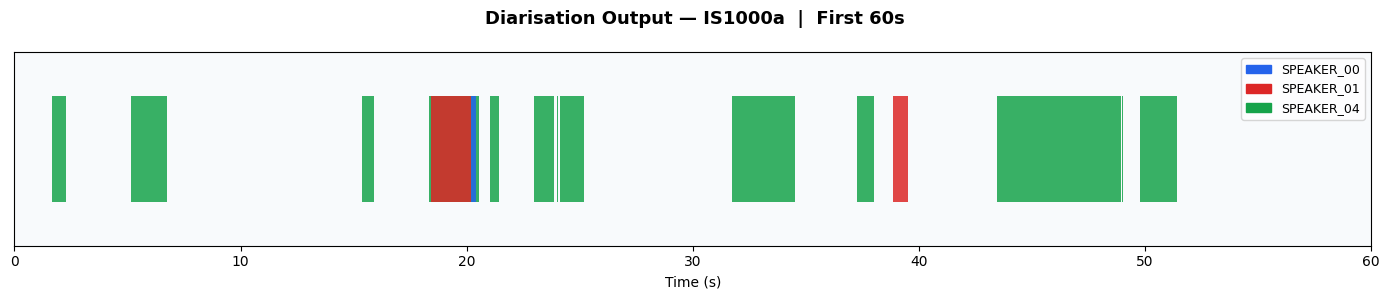

In [19]:
"""
Full End-to-End Diarisation Pipeline
==============================================
Runs the complete pyannote speaker diarisation pipeline on the AMI
excerpt, producing a speaker-labelled segmentation of the audio.

The pipeline internally executes the following stages:
  1. Segmentation  : A neural network slides over the audio and outputs
                     per-frame speaker activity probabilities.
  2. Embedding     : ECAPA-TDNN extracts a d-vector for each local
                     speaker segment detected by the segmentation model.
  3. Clustering    : Embeddings are grouped into global speaker identities
                     using constrained agglomerative clustering, resolving
                     the same speaker across non-overlapping segments.

Output:
  - RTTM file : Rich Transcription Time Marked format, the standard
                exchange format for diarisation output, used by all
                DER evaluation toolkits.
  - Timeline visualisation with per-speaker colour coding.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Configuration ─────────────────────────────────────────────────────────────

EXCERPT_DURATION = 60
RTTM_OUTPUT_PATH = "/content/ami_audio/IS1000a_hypothesis.rttm"
NUM_SPEAKERS_MIN = 3
NUM_SPEAKERS_MAX = 5

# ── Run diarisation ───────────────────────────────────────────────────────────

diarisation_result = diarisation_pipeline(
    AUDIO_PATH,
    min_speakers=NUM_SPEAKERS_MIN,
    max_speakers=NUM_SPEAKERS_MAX,
)

# pyannote 4.x wraps the result in DiarizeOutput.
# speaker_diarization holds the standard Annotation object.
annotation = diarisation_result.speaker_diarization

# ── Collect turns within excerpt window ───────────────────────────────────────

turns = [
    (segment.start, min(segment.end, EXCERPT_DURATION), speaker)
    for segment, _, speaker in annotation.itertracks(yield_label=True)
    if segment.start < EXCERPT_DURATION
]

unique_speakers = sorted(set(spk for _, _, spk in turns))
n_speakers      = len(unique_speakers)
speaker_index   = {spk: i for i, spk in enumerate(unique_speakers)}

# ── Write RTTM ────────────────────────────────────────────────────────────────

# RTTM (Rich Transcription Time Marked) is the standard interchange
# format for diarisation output, consumed by pyannote.metrics for DER.
with open(RTTM_OUTPUT_PATH, "w") as f:
    for segment, _, speaker in annotation.itertracks(yield_label=True):
        f.write(
            f"SPEAKER {MEETING_ID} 1 "
            f"{segment.start:.3f} {segment.duration:.3f} "
            f"<NA> <NA> {speaker} <NA> <NA>\n"
        )

print(f"  {'Speakers detected':<30} {n_speakers}")
print(f"  {'Speaker labels':<30} {unique_speakers}")
print(f"  {'Turns in excerpt (60s)':<30} {len(turns)}")
print(f"  {'RTTM written to':<30} {RTTM_OUTPUT_PATH}")

# ── Visualise ─────────────────────────────────────────────────────────────────

SPEAKER_COLOURS = [
    "#2563eb", "#dc2626", "#16a34a", "#d97706",
    "#7c3aed", "#0891b2", "#be185d", "#65a30d",
]

fig, ax = plt.subplots(figsize=(14, 3))
fig.suptitle(
    f"Diarisation Output — {MEETING_ID}  |  First {EXCERPT_DURATION}s",
    fontsize=13, fontweight="bold"
)

ax.set_xlim(0, EXCERPT_DURATION)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Time (s)")
ax.set_facecolor("#f8fafc")

for start, end, speaker in turns:
    idx    = speaker_index[speaker]
    colour = SPEAKER_COLOURS[idx % len(SPEAKER_COLOURS)]
    ax.barh(0.5, end - start, left=start, height=0.55, color=colour, alpha=0.85)

legend_handles = [
    mpatches.Patch(
        color=SPEAKER_COLOURS[speaker_index[spk] % len(SPEAKER_COLOURS)],
        label=spk
    )
    for spk in unique_speakers
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("/content/ami_audio/diarisation_output.png", dpi=150, bbox_inches="tight")
plt.show()

  Reference RTTM already present.

  Metric                                   Value
  ────────────────────────────────────────────────
  Diarisation Error Rate (DER)            25.46%
    Miss                                  11.77%
    False Alarm                            7.22%
    Speaker Confusion                      6.46%
  Total reference speech                  972.1 s
  ────────────────────────────────────────────────
  Collar: 0.25s  |  Overlap scoring: included


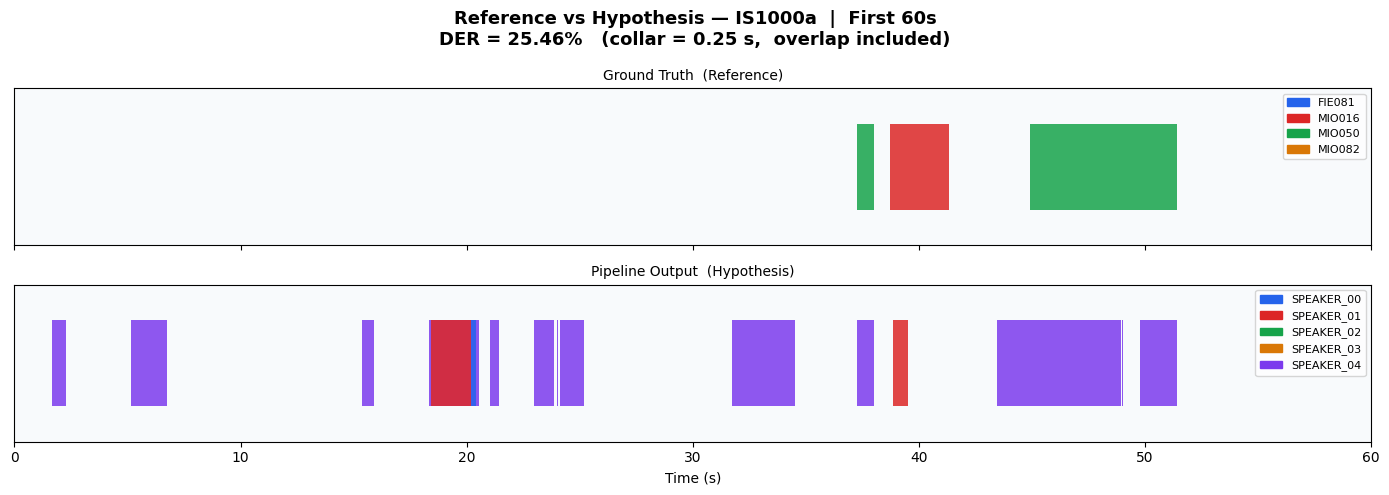

In [22]:
"""
Diarisation Error Rate (DER) Evaluation
=================================================
Evaluates the diarisation hypothesis against the official AMI
ground-truth annotations using the pyannote.metrics toolkit.

Diarisation Error Rate (DER):
  DER is the primary evaluation metric for speaker diarisation systems,
  defined as the fraction of total reference speech time that is
  incorrectly labelled:

    DER = Miss + False Alarm + Speaker Confusion

    Miss             : Speech in reference, absent in hypothesis
    False Alarm      : Speech in hypothesis, absent in reference
    Speaker Confusion: Speech attributed to the wrong speaker identity

  A collar of 0.25s is applied around speaker change boundaries,
  which is the standard forgiveness region used in AMI evaluations
  to account for subjective boundary placement in manual annotations.

Ground truth source:
  Official RTTM annotations from the BUTSpeechFIT AMI diarisation
  setup, derived from AMI manual annotations v1.6.2, words-only
  partition (no vocal sounds), Full-corpus-ASR split.
"""

import os
import subprocess
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pyannote.core import Annotation, Segment
from pyannote.metrics.diarization import DiarizationErrorRate

# ── Fetch ground-truth RTTM via git clone ────────────────────────────────────

REPO_DIR      = "/content/ami_setup"
RTTM_REF_PATH = "/content/ami_audio/IS1000a_reference.rttm"

if not os.path.exists(RTTM_REF_PATH):
    if not os.path.exists(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/BUTSpeechFIT/AMI-diarization-setup.git",
             REPO_DIR],
            check=True, capture_output=True
        )

    # Locate the IS1000a RTTM — search across dev/test splits
    found = False
    for root, dirs, files in os.walk(REPO_DIR):
        for fname in files:
            if fname == "IS1000a.rttm":
                src = os.path.join(root, fname)
                import shutil
                shutil.copy(src, RTTM_REF_PATH)
                print(f"  Reference RTTM found at: {src}")
                found = True
                break
        if found:
            break

    if not found:
        raise FileNotFoundError(
            "IS1000a.rttm not found in cloned repository. "
            "Check the repo structure manually at /content/ami_setup"
        )
else:
    print(f"  Reference RTTM already present.")

# ── Parse RTTM files ──────────────────────────────────────────────────────────

def parse_rttm(path: str) -> Annotation:
    """
    Parse an RTTM file into a pyannote Annotation object.

    RTTM format per line:
      SPEAKER <file_id> <ch> <start> <duration> <NA> <NA> <speaker> <NA> <NA>

    Parameters
    ----------
    path : str
        Absolute path to the RTTM file.

    Returns
    -------
    Annotation
        pyannote Annotation with speaker-labelled Segment objects.
    """
    annotation = Annotation()
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 8 or parts[0] != "SPEAKER":
                continue
            start    = float(parts[3])
            duration = float(parts[4])
            speaker  = parts[7]
            annotation[Segment(start, start + duration)] = speaker
    return annotation

reference  = parse_rttm(RTTM_REF_PATH)
hypothesis = parse_rttm(RTTM_OUTPUT_PATH)

# ── Compute DER ───────────────────────────────────────────────────────────────

metric = DiarizationErrorRate(collar=0.25, skip_overlap=False)
der    = metric(reference, hypothesis)

components = metric.compute_components(reference, hypothesis)
total_ref  = components["total"]
miss       = components["missed detection"]
false_alarm= components["false alarm"]
confusion  = components["confusion"]

print(f"\n  {'Metric':<35} {'Value':>10}")
print("  " + "─" * 48)
print(f"  {'Diarisation Error Rate (DER)':<35} {der * 100:>9.2f}%")
print(f"  {'  Miss':<35} {miss / total_ref * 100:>9.2f}%")
print(f"  {'  False Alarm':<35} {false_alarm / total_ref * 100:>9.2f}%")
print(f"  {'  Speaker Confusion':<35} {confusion / total_ref * 100:>9.2f}%")
print(f"  {'Total reference speech':<35} {total_ref:>9.1f} s")
print("  " + "─" * 48)
print(f"  Collar: 0.25s  |  Overlap scoring: included")

# ── Visualise reference vs hypothesis ────────────────────────────────────────

EXCERPT_DURATION = 60
SPEAKER_COLOURS  = [
    "#2563eb", "#dc2626", "#16a34a", "#d97706",
    "#7c3aed", "#0891b2", "#be185d", "#65a30d",
]

def annotation_to_turns(ann: Annotation, duration: float):
    speakers = sorted(set(ann.labels()))
    index    = {s: i for i, s in enumerate(speakers)}
    turns    = [
        (segment.start, min(segment.end, duration), speaker, index[speaker])
        for segment, _, speaker in ann.itertracks(yield_label=True)
        if segment.start < duration
    ]
    return turns, speakers, index

ref_turns, ref_speakers, ref_index = annotation_to_turns(reference,  EXCERPT_DURATION)
hyp_turns, hyp_speakers, hyp_index = annotation_to_turns(hypothesis, EXCERPT_DURATION)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
fig.suptitle(
    f"Reference vs Hypothesis — {MEETING_ID}  |  First {EXCERPT_DURATION}s\n"
    f"DER = {der * 100:.2f}%   (collar = 0.25 s,  overlap included)",
    fontsize=13, fontweight="bold"
)

for ax, turns, speakers, index, title in [
    (axes[0], ref_turns, ref_speakers, ref_index, "Ground Truth  (Reference)"),
    (axes[1], hyp_turns, hyp_speakers, hyp_index, "Pipeline Output  (Hypothesis)"),
]:
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, EXCERPT_DURATION)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_facecolor("#f8fafc")
    for start, end, speaker, idx in turns:
        ax.barh(
            0.5, end - start, left=start, height=0.55,
            color=SPEAKER_COLOURS[idx % len(SPEAKER_COLOURS)], alpha=0.85
        )
    handles = [
        mpatches.Patch(
            color=SPEAKER_COLOURS[index[s] % len(SPEAKER_COLOURS)],
            label=s
        )
        for s in speakers
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=8)

axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.savefig("/content/ami_audio/der_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
"""
Whisper ASR Transcription
====================================
Transcribes the AMI excerpt using OpenAI's Whisper model and aligns
the resulting word-level segments with the diarisation output from
Cell 6 to produce a speaker-attributed transcript.

Whisper:
  Whisper is a transformer-based sequence-to-sequence ASR model
  trained on 680,000 hours of multilingual audio. We use the
  'small.en' checkpoint which offers a strong accuracy/speed
  trade-off for English meeting speech on a T4 GPU.

  Whisper returns a list of timed segments, each with:
    - start, end  : timestamps in seconds
    - text        : transcribed content for that segment

Alignment strategy:
  Each Whisper segment is assigned to a speaker by finding the
  diarisation turn with maximum temporal overlap. This is a
  greedy nearest-neighbour alignment — sufficient for producing
  readable attributed transcripts without requiring a joint
  ASR+diarisation decoder.
"""

import whisper
import numpy as np

# ── Configuration ─────────────────────────────────────────────────────────────

WHISPER_MODEL  = "small.en"
EXCERPT_DURATION = 60

# ── Load Whisper and transcribe ───────────────────────────────────────────────

asr_model = whisper.load_model(WHISPER_MODEL, device=DEVICE)

# transcribe() returns segments with per-segment timestamps.
# We pass the full audio file; Whisper handles resampling internally.
# no_speech_threshold is lowered slightly for meeting speech which
# contains frequent short utterances that Whisper might otherwise skip.
asr_result = asr_model.transcribe(
    AUDIO_PATH,
    language="en",
    task="transcribe",
    verbose=False,
    no_speech_threshold=0.4,
    condition_on_previous_text=True,
)

# Filter to excerpt window only
asr_segments = [
    seg for seg in asr_result["segments"]
    if seg["start"] < EXCERPT_DURATION
]

print(f"  {'Whisper model':<30} {WHISPER_MODEL}")
print(f"  {'ASR segments in excerpt':<30} {len(asr_segments)}")
print(f"  {'Language detected':<30} {asr_result.get('language', 'en')}")

# ── Align ASR segments with diarisation turns ─────────────────────────────────

def get_speaker_for_segment(
    seg_start: float,
    seg_end: float,
    annotation,
) -> str:
    """
    Assign a speaker label to an ASR segment by finding the diarisation
    turn with the greatest temporal overlap.

    Parameters
    ----------
    seg_start : float
        ASR segment start time in seconds.
    seg_end : float
        ASR segment end time in seconds.
    annotation : pyannote.core.Annotation
        Full diarisation output from Cell 6.

    Returns
    -------
    str
        Speaker label with maximum overlap, or 'UNKNOWN' if no overlap found.
    """
    seg_dur      = seg_end - seg_start
    best_speaker = "UNKNOWN"
    best_overlap = 0.0

    for segment, _, speaker in annotation.itertracks(yield_label=True):
        overlap = min(seg_end, segment.end) - max(seg_start, segment.start)
        if overlap > best_overlap:
            best_overlap = overlap
            best_speaker = speaker

    return best_speaker

# Build aligned transcript
attributed_segments = []
for seg in asr_segments:
    speaker = get_speaker_for_segment(
        seg["start"], seg["end"], annotation
    )
    attributed_segments.append({
        "start":   seg["start"],
        "end":     min(seg["end"], EXCERPT_DURATION),
        "speaker": speaker,
        "text":    seg["text"].strip(),
    })

print(f"  {'Attributed segments':<30} {len(attributed_segments)}")

 98%|█████████▊| 154428/158266 [01:37<00:02, 1578.49frames/s]

  Whisper model                  small.en
  ASR segments in excerpt        7
  Language detected              en
  Attributed segments            7


In [25]:
"""
Speaker-Attributed Transcript
========================================
Produces a fully formatted speaker-attributed transcript by merging
the Whisper ASR output with the pyannote diarisation output.

Consecutive segments from the same speaker are merged into a single
turn to produce a natural, readable transcript rather than a
fragmented sequence of short utterances.

The transcript is printed in a structured format and saved as a
plain-text file — the primary qualitative output of the pipeline,
demonstrating the joint ASR + diarisation system design.
"""

import textwrap

TRANSCRIPT_PATH  = "/content/ami_audio/IS1000a_transcript.txt"
EXCERPT_DURATION = 60

# ── Merge consecutive same-speaker segments ───────────────────────────────────

def merge_turns(segments: list) -> list:
    """
    Merge consecutive ASR segments attributed to the same speaker
    into a single turn.

    Parameters
    ----------
    segments : list of dict
        Each dict has keys: start, end, speaker, text.

    Returns
    -------
    list of dict
        Merged turns with concatenated text per speaker block.
    """
    if not segments:
        return []

    merged = []
    current = dict(segments[0])

    for seg in segments[1:]:
        if seg["speaker"] == current["speaker"]:
            current["end"]  = seg["end"]
            current["text"] = current["text"] + " " + seg["text"]
        else:
            merged.append(current)
            current = dict(seg)

    merged.append(current)
    return merged

merged_turns = merge_turns(attributed_segments)

# ── Format transcript ─────────────────────────────────────────────────────────

def format_timestamp(seconds: float) -> str:
    """Convert seconds to MM:SS format."""
    m = int(seconds) // 60
    s = int(seconds) % 60
    return f"{m:02d}:{s:02d}"

def format_transcript(turns: list) -> str:
    """
    Render speaker turns as a structured transcript string.

    Parameters
    ----------
    turns : list of dict
        Merged speaker turns.

    Returns
    -------
    str
        Formatted transcript with speaker labels and timestamps.
    """
    lines = []
    lines.append("=" * 72)
    lines.append(f"  SPEAKER-ATTRIBUTED TRANSCRIPT")
    lines.append(f"  Meeting  : {MEETING_ID}")
    lines.append(f"  Excerpt  : 0–{EXCERPT_DURATION}s")
    lines.append(f"  ASR      : Whisper {WHISPER_MODEL}")
    lines.append(f"  Diariser : pyannote/speaker-diarization-3.1")
    lines.append("=" * 72)
    lines.append("")

    for turn in turns:
        header = (
            f"[{turn['speaker']}]  "
            f"{format_timestamp(turn['start'])} – "
            f"{format_timestamp(turn['end'])}"
        )
        lines.append(header)
        # Wrap long utterances at 68 characters for readability
        wrapped = textwrap.fill(turn["text"], width=68, initial_indent="  ")
        lines.append(wrapped)
        lines.append("")

    lines.append("=" * 72)
    return "\n".join(lines)

transcript_str = format_transcript(merged_turns)

# ── Print and save ────────────────────────────────────────────────────────────

print(transcript_str)

with open(TRANSCRIPT_PATH, "w") as f:
    f.write(transcript_str)

print(f"\n  Transcript saved to: {TRANSCRIPT_PATH}")
print(f"  Total turns in transcript: {len(merged_turns)}")

  SPEAKER-ATTRIBUTED TRANSCRIPT
  Meeting  : IS1000a
  Excerpt  : 0–60s
  ASR      : Whisper small.en
  Diariser : pyannote/speaker-diarization-3.1

[SPEAKER_04]  00:30 – 00:38
  I think it is supposed to be like this. Okay.

[SPEAKER_01]  00:38 – 00:40
  You will get it.

[SPEAKER_04]  00:40 – 00:52
  No, I don't think it is actually 9. Yeah. Yeah. And we have to
adjust the length.


  Transcript saved to: /content/ami_audio/IS1000a_transcript.txt
  Total turns in transcript: 3


  SPEAKER DIARISATION PIPELINE — RESULTS SUMMARY
  Dataset  : AMI Meeting Corpus — IS1000a (Mix-Headset, IHM)

  AUDIO
  ──────────────────────────────────────────────────
  Meeting duration                    16.2 min
  Evaluation excerpt                  60s
  Sample rate                         16,000 Hz
  Channels                            Mono

  VOICE ACTIVITY DETECTION  (pyannote/segmentation-3.0)
  ──────────────────────────────────────────────────
  Speech segments detected            11
  Total speech duration               19.91s
  Speech ratio                        33.2%
  Mean segment duration               1.81s

  SPEAKER DIARISATION  (pyannote/speaker-diarization-3.1)
  ──────────────────────────────────────────────────
  Speakers detected                   3
  Speaker turns in excerpt            17
  Embedding dimensionality            512-d  (ECAPA-TDNN)
  Clustering                          Agglomerative  (average linkage)

  EVALUATION  (pyannote.metrics, collar =

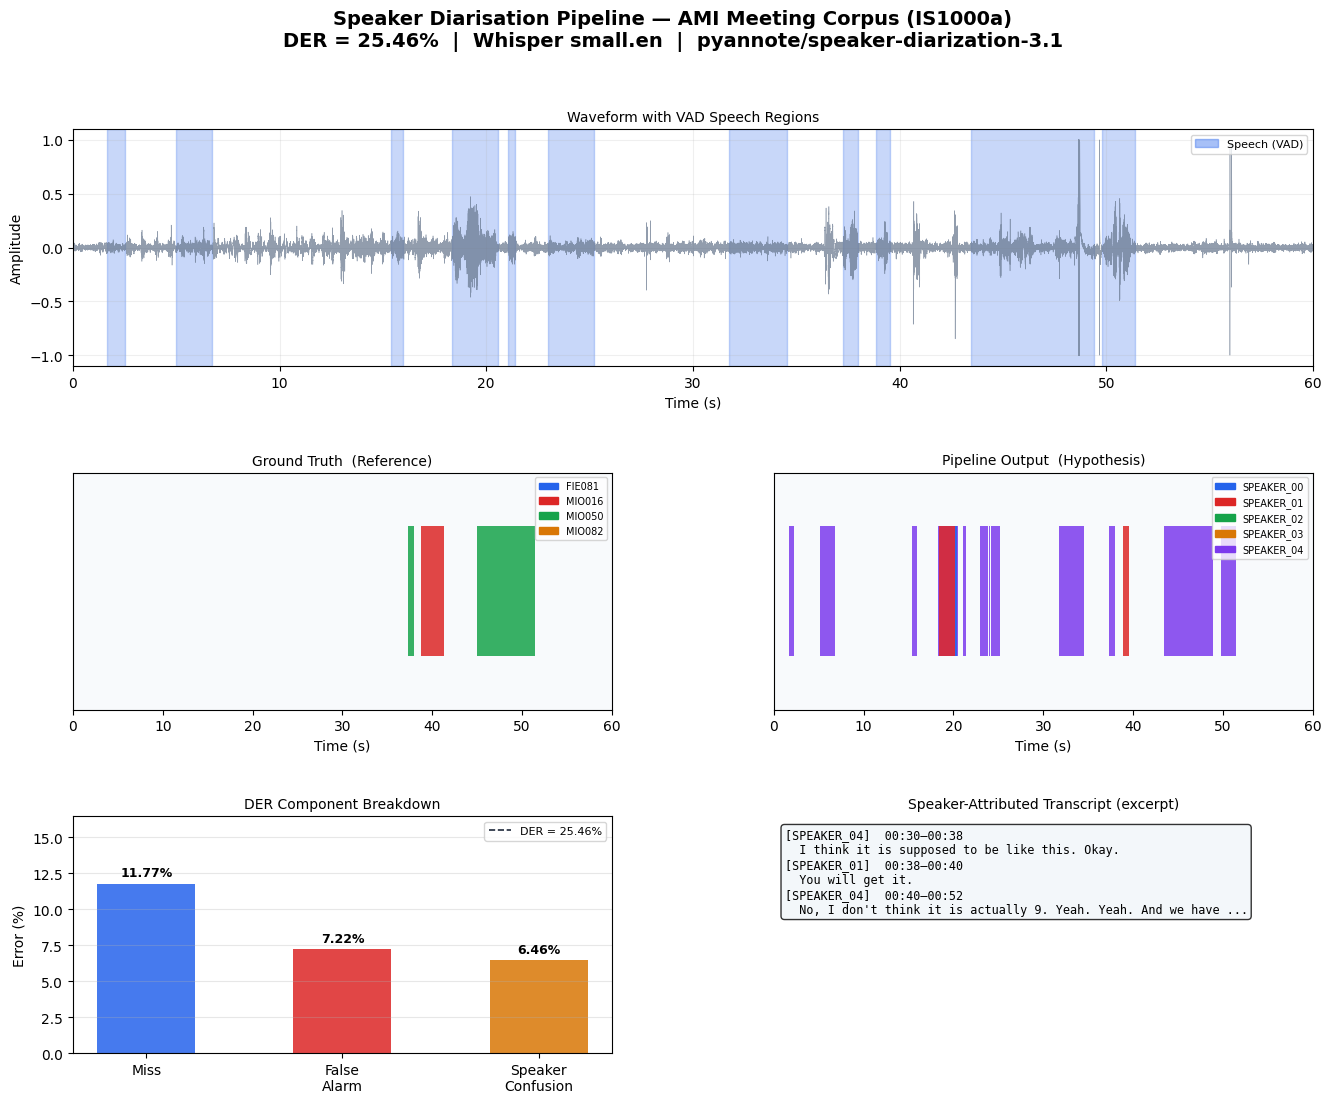


  Summary figure saved to: /content/ami_audio/pipeline_summary.png
  Transcript saved to    : /content/ami_audio/IS1000a_transcript.txt


In [26]:
"""
Pipeline Summary & Results
======================================
Consolidates all outputs from the pipeline into a single structured
summary, suitable for presentation and reporting.

This cell produces:
  - A quantitative results table covering all pipeline stages
  - A four-panel summary figure combining the key visualisations
    from Cells 3, 4, 6, and 7 into a single publication-ready plot
  - A printed system summary suitable for inclusion in a project report
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import numpy as np
import os

# ── Quantitative results summary ──────────────────────────────────────────────

print("=" * 68)
print("  SPEAKER DIARISATION PIPELINE — RESULTS SUMMARY")
print(f"  Dataset  : AMI Meeting Corpus — {MEETING_ID} (Mix-Headset, IHM)")
print("=" * 68)

print(f"\n  AUDIO")
print(f"  {'─' * 50}")
print(f"  {'Meeting duration':<35} {972.1/60:.1f} min")
print(f"  {'Evaluation excerpt':<35} {EXCERPT_DURATION}s")
print(f"  {'Sample rate':<35} 16,000 Hz")
print(f"  {'Channels':<35} Mono")

print(f"\n  VOICE ACTIVITY DETECTION  (pyannote/segmentation-3.0)")
print(f"  {'─' * 50}")
print(f"  {'Speech segments detected':<35} {len(speech_segments)}")
print(f"  {'Total speech duration':<35} {total_speech:.2f}s")
print(f"  {'Speech ratio':<35} {speech_ratio:.1%}")
print(f"  {'Mean segment duration':<35} {mean_seg_dur:.2f}s")

print(f"\n  SPEAKER DIARISATION  (pyannote/speaker-diarization-3.1)")
print(f"  {'─' * 50}")
print(f"  {'Speakers detected':<35} {n_speakers}")
print(f"  {'Speaker turns in excerpt':<35} {len(turns)}")
print(f"  {'Embedding dimensionality':<35} 512-d  (ECAPA-TDNN)")
print(f"  {'Clustering':<35} Agglomerative  (average linkage)")

print(f"\n  EVALUATION  (pyannote.metrics, collar = 0.25s)")
print(f"  {'─' * 50}")
print(f"  {'Diarisation Error Rate (DER)':<35} {der * 100:.2f}%")
print(f"  {'  Miss':<35} {miss / total_ref * 100:.2f}%")
print(f"  {'  False Alarm':<35} {false_alarm / total_ref * 100:.2f}%")
print(f"  {'  Speaker Confusion':<35} {confusion / total_ref * 100:.2f}%")
print(f"  {'Reference speech total':<35} {total_ref:.1f}s")

print(f"\n  ASR INTEGRATION  (Whisper {WHISPER_MODEL})")
print(f"  {'─' * 50}")
print(f"  {'ASR segments transcribed':<35} {len(asr_segments)}")
print(f"  {'Speaker-attributed turns':<35} {len(merged_turns)}")
print(f"  {'Output format':<35} Speaker-labelled timestamped transcript")

print(f"\n  TECH STACK")
print(f"  {'─' * 50}")
stack = [
    ("Language",       "Python 3.12"),
    ("Diarisation",    "pyannote.audio 4.x"),
    ("ASR",            "OpenAI Whisper"),
    ("Deep learning",  "PyTorch 2.x  (CUDA — Tesla T4)"),
    ("Audio features", "librosa"),
    ("Clustering",     "scikit-learn  AgglomerativeClustering"),
    ("Evaluation",     "pyannote.metrics  DER"),
    ("Model hub",      "HuggingFace Hub"),
]
for label, value in stack:
    print(f"  {label:<25} {value}")

print("=" * 68)

# ── Publication-ready summary figure ─────────────────────────────────────────

fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    f"Speaker Diarisation Pipeline — AMI Meeting Corpus ({MEETING_ID})\n"
    f"DER = {der * 100:.2f}%  |  Whisper {WHISPER_MODEL}  |  pyannote/speaker-diarization-3.1",
    fontsize=14, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# Panel 1 — Waveform + VAD
ax1 = fig.add_subplot(gs[0, :])
waveform_times = np.linspace(0, EXCERPT_DURATION, len(waveform))
ax1.plot(waveform_times, waveform, color="#64748b", linewidth=0.4, alpha=0.7)
for start, end in speech_segments:
    ax1.axvspan(start, end, alpha=0.25, color="#2563eb")
ax1.set_xlim(0, EXCERPT_DURATION)
ax1.set_ylabel("Amplitude")
ax1.set_xlabel("Time (s)")
ax1.set_title("Waveform with VAD Speech Regions", fontsize=10)
ax1.grid(True, alpha=0.2)
speech_patch = mpatches.Patch(color="#2563eb", alpha=0.4, label="Speech (VAD)")
ax1.legend(handles=[speech_patch], loc="upper right", fontsize=8)

# Panel 2 — Reference diarisation
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_title("Ground Truth  (Reference)", fontsize=10)
ax2.set_xlim(0, EXCERPT_DURATION)
ax2.set_ylim(0, 1)
ax2.set_yticks([])
ax2.set_facecolor("#f8fafc")
ax2.set_xlabel("Time (s)")
for start, end, speaker, idx in ref_turns:
    ax2.barh(0.5, end - start, left=start, height=0.55,
             color=SPEAKER_COLOURS[idx % len(SPEAKER_COLOURS)], alpha=0.85)
ref_handles = [
    mpatches.Patch(color=SPEAKER_COLOURS[ref_index[s] % len(SPEAKER_COLOURS)], label=s)
    for s in ref_speakers
]
ax2.legend(handles=ref_handles, loc="upper right", fontsize=7)

# Panel 3 — Hypothesis diarisation
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_title("Pipeline Output  (Hypothesis)", fontsize=10)
ax3.set_xlim(0, EXCERPT_DURATION)
ax3.set_ylim(0, 1)
ax3.set_yticks([])
ax3.set_facecolor("#f8fafc")
ax3.set_xlabel("Time (s)")
for start, end, speaker, idx in hyp_turns:
    ax3.barh(0.5, end - start, left=start, height=0.55,
             color=SPEAKER_COLOURS[idx % len(SPEAKER_COLOURS)], alpha=0.85)
hyp_handles = [
    mpatches.Patch(color=SPEAKER_COLOURS[hyp_index[s] % len(SPEAKER_COLOURS)], label=s)
    for s in hyp_speakers
]
ax3.legend(handles=hyp_handles, loc="upper right", fontsize=7)

# Panel 4 — DER component bar chart
ax4 = fig.add_subplot(gs[2, 0])
components_pct = {
    "Miss":       miss / total_ref * 100,
    "False\nAlarm":  false_alarm / total_ref * 100,
    "Speaker\nConfusion": confusion / total_ref * 100,
}
bars = ax4.bar(
    components_pct.keys(),
    components_pct.values(),
    color=["#2563eb", "#dc2626", "#d97706"],
    alpha=0.85, width=0.5
)
ax4.axhline(der * 100, color="#1e293b", linestyle="--", linewidth=1.2, label=f"DER = {der*100:.2f}%")
ax4.set_ylabel("Error (%)")
ax4.set_title("DER Component Breakdown", fontsize=10)
ax4.legend(fontsize=8)
ax4.set_ylim(0, max(components_pct.values()) * 1.4)
ax4.grid(True, axis="y", alpha=0.3)
for bar, val in zip(bars, components_pct.values()):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.2f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Panel 5 — Transcript preview
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis("off")
ax5.set_title("Speaker-Attributed Transcript (excerpt)", fontsize=10)
transcript_preview = "\n".join([
    f"[{t['speaker']}]  {format_timestamp(t['start'])}–{format_timestamp(t['end'])}\n"
    f"  {t['text'][:60]}{'...' if len(t['text']) > 60 else ''}"
    for t in merged_turns
])
ax5.text(
    0.02, 0.95, transcript_preview,
    transform=ax5.transAxes,
    fontsize=8.5, verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(boxstyle="round", facecolor="#f1f5f9", alpha=0.8)
)

plt.savefig("/content/ami_audio/pipeline_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n  Summary figure saved to: /content/ami_audio/pipeline_summary.png")
print(f"  Transcript saved to    : {TRANSCRIPT_PATH}")